# Fraud Detection — CTGAN

## 1. Setup + hyperparams

In [ ]:
# === Phải set TRƯỚC khi import numpy/sklearn/xgboost ===
# Tránh xung đột OpenMP gây kernel restart trên macOS.
import os
os.environ['KMP_DUPLICATE_LIB_OK']     = 'TRUE'
os.environ['OMP_NUM_THREADS']          = '1'
os.environ['OPENBLAS_NUM_THREADS']     = '1'
os.environ['MKL_NUM_THREADS']          = '1'
os.environ['VECLIB_MAXIMUM_THREADS']   = '1'
os.environ['NUMEXPR_NUM_THREADS']      = '1'

import warnings, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

NB_DIR  = Path('.').resolve()
RAW_CSV = NB_DIR / 'dataset' / 'data_FraudDetection_JAR2020.csv'
DATA_DIR = NB_DIR / 'data'
OUT_DIR  = NB_DIR / 'outputs'
FIG_DIR  = OUT_DIR / 'figures'
TAB_DIR  = OUT_DIR / 'tables'
MOD_DIR  = OUT_DIR / 'models'
for d in (DATA_DIR, FIG_DIR, TAB_DIR, MOD_DIR):
    d.mkdir(parents=True, exist_ok=True)

LABEL = 'misstate'
RAW_FEATURES = ['act','ap','at','ceq','che','cogs','csho','dlc','dltis','dltt',
    'dp','ib','invt','ivao','ivst','lct','lt','ni','ppegt','pstk',
    're','rect','sale','sstk','txp','txt','xint','prcc_f']
RATIO_FEATURES = ['dch_wc','ch_rsst','dch_rec','dch_inv','soft_assets','ch_cs',
    'ch_cm','ch_roa','issue','bm','dpi','reoa','EBIT','ch_fcf']

# === BẬT 42 features (28 raw + 14 ratio) ===
USE_RATIOS = True
FEATURES = RAW_FEATURES if not USE_RATIOS else RAW_FEATURES + RATIO_FEATURES
print(f'Sử dụng {len(FEATURES)} features (USE_RATIOS={USE_RATIOS})')

# Biến luôn ≥0 để log1p; biến có thể âm thì giữ nguyên (signed_log không áp dụng)
POSITIVE_FEATURES = ['act','ap','at','ceq','che','cogs','csho','dlc','dltis',
    'dltt','dp','invt','ivao','ivst','lct','lt','ppegt','pstk','rect','sale',
    'sstk','txp','txt','xint','prcc_f','soft_assets']

# === Split ===
TRAIN_YEARS = (1991, 2002)
VAL_YEARS   = (2003, 2005)
TEST_YEARS  = (2006, 2008)

SEEDS = [42, 7, 123]

# === Winsorize đuôi cực ===
WINSORIZE_QUANTILE = (0.01, 0.99)   # clip 1%-99%

# === RobustScaler thay StandardScaler ===
USE_ROBUST_SCALER = True

# === CTGAN small (phù hợp ~576 fraud) ===
CTGAN_EPOCHS  = 800
CTGAN_BATCH   = 300       # phải chia hết cho 10
CTGAN_LR      = 1e-4
CTGAN_GEN_DIM = (128, 128)
CTGAN_DISC_DIM = (128, 128)
CTGAN_EMBED   = 64
CTGAN_DSTEPS  = 3
N_SYNTH_RATIO = 2         # synth = N_SYNTH_RATIO × len(fraudDf)
K_PERCENTS    = [1, 2, 5, 10]

# === XGB pos_weight cho imbalance ===
XGB_SCALE_POS_WEIGHT = 50

assert CTGAN_BATCH % 10 == 0
print('Split:', TRAIN_YEARS, '|', VAL_YEARS, '|', TEST_YEARS)
print('CTGAN:', f'epochs={CTGAN_EPOCHS} batch={CTGAN_BATCH} lr={CTGAN_LR} gen={CTGAN_GEN_DIM} embed={CTGAN_EMBED}')
print('Preprocess: winsorize=', WINSORIZE_QUANTILE, '| RobustScaler=', USE_ROBUST_SCALER)


## 2. EDA

In [ ]:
raw = pd.read_csv(RAW_CSV)
print('Shape:', raw.shape, '| Năm:', raw['fyear'].min(), '-', raw['fyear'].max())
total = len(raw); pos = int(raw[LABEL].sum())
print(f'Tổng: {total} | Gian lận: {pos} ({pos/total*100:.2f}%)')

Shape: (146045, 46) | Năm: 1990 - 2014
Tổng: 146045 | Gian lận: 964 (0.66%)


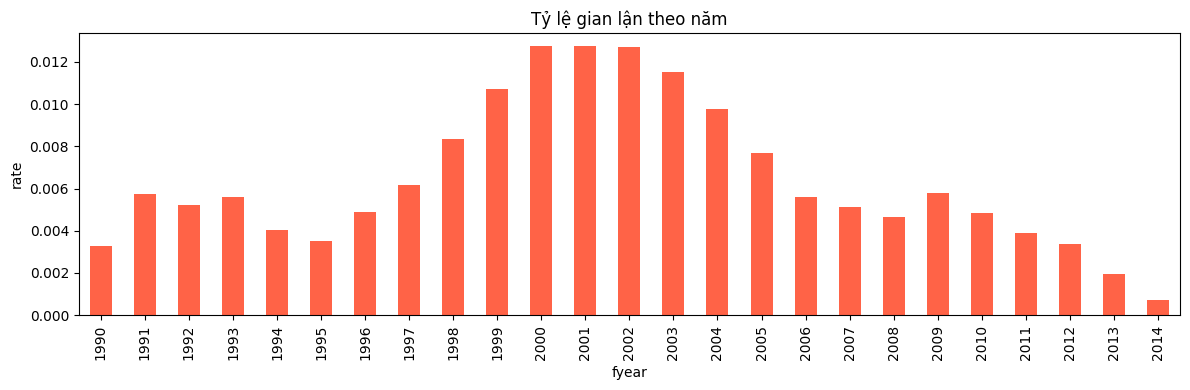

In [ ]:
byYear = raw.groupby('fyear')[LABEL].agg(['sum','count','mean'])
byYear.columns = ['fraud','total','rate']
byYear.to_csv(TAB_DIR/'fraudByYear.csv')
fig, ax = plt.subplots(figsize=(12,4))
byYear['rate'].plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Tỷ lệ gian lận theo năm'); ax.set_ylabel('rate')
plt.tight_layout(); plt.savefig(FIG_DIR/'fraudByYear.png', dpi=120); plt.show()

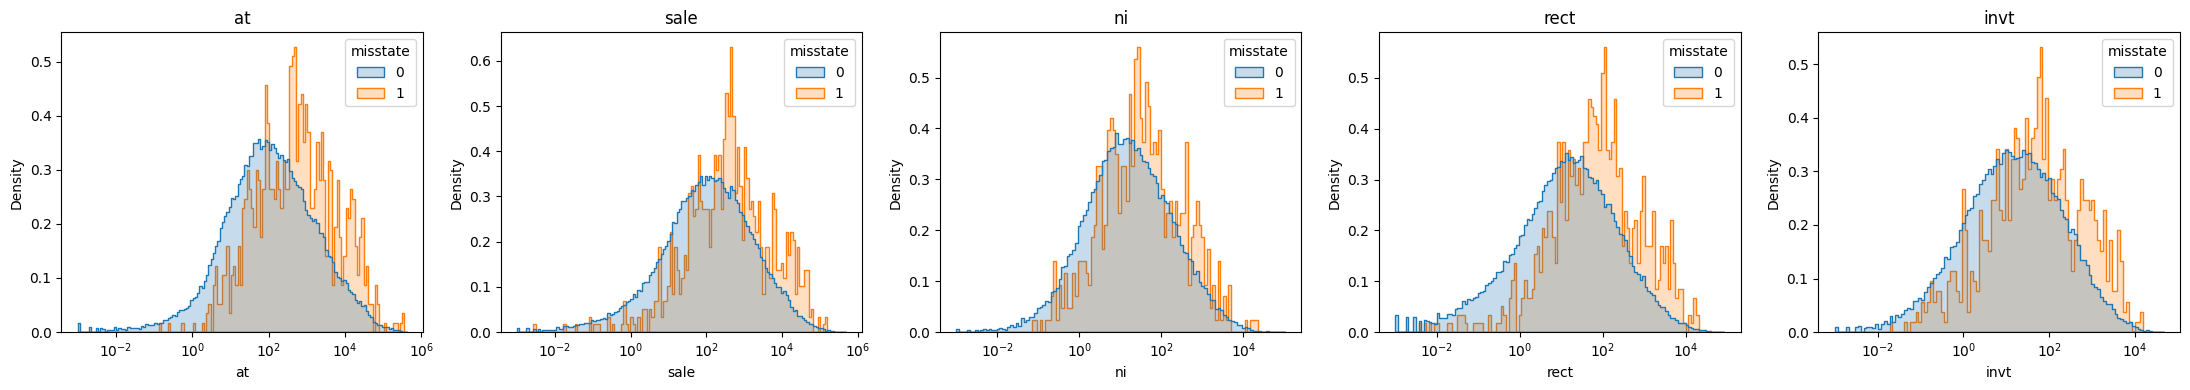

In [ ]:
keyVars = ['at','sale','ni','rect','invt']
fig, axes = plt.subplots(1, 5, figsize=(22,4))
for ax, v in zip(axes, keyVars):
    d = raw[[v, LABEL]].dropna(); d = d[d[v]>0]
    sns.histplot(data=d, x=v, hue=LABEL, log_scale=True, ax=ax,
                 element='step', stat='density', common_norm=False)
    ax.set_title(v)
plt.tight_layout(); plt.savefig(FIG_DIR/'distributions.png', dpi=120); plt.show()

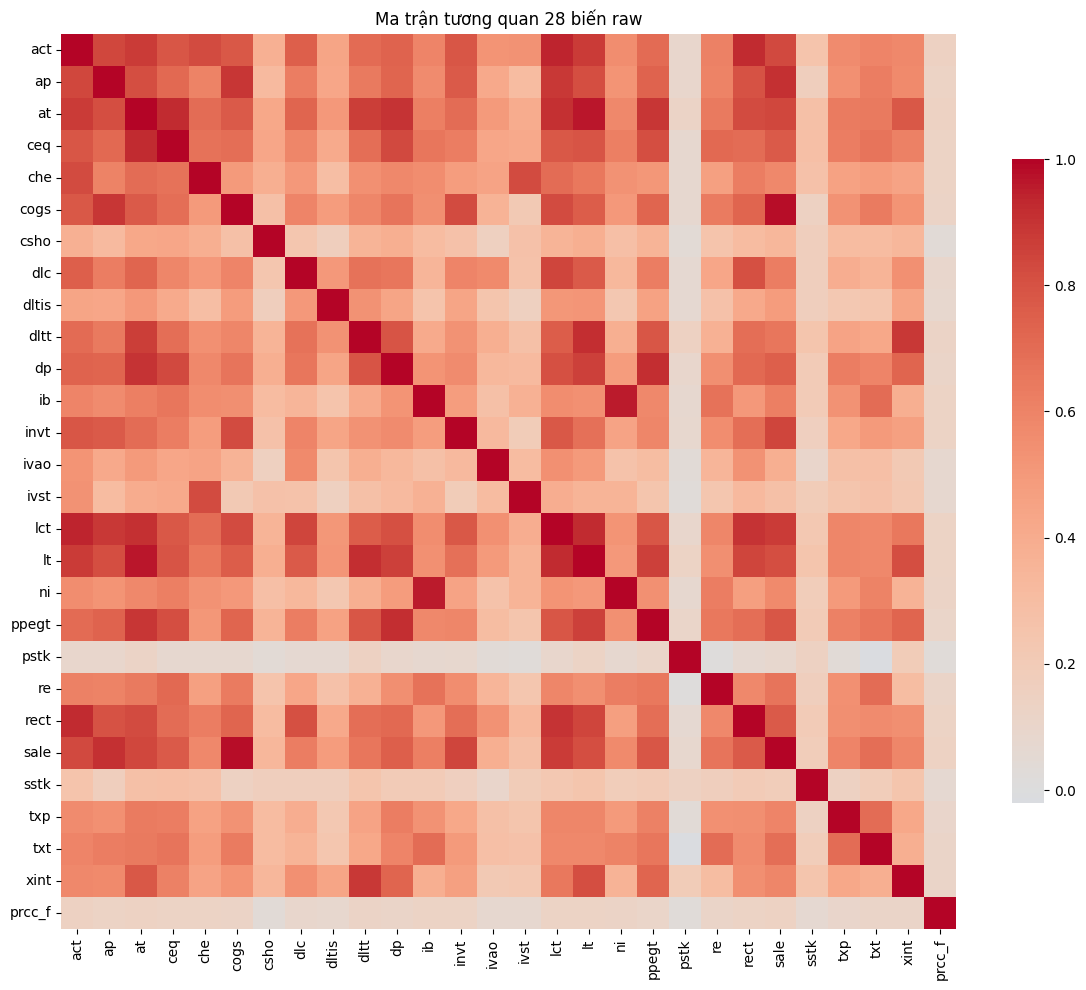

In [ ]:
corr = raw[RAW_FEATURES].corr()
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'shrink':0.7})
ax.set_title('Ma trận tương quan 28 biến raw')
plt.tight_layout(); plt.savefig(FIG_DIR/'correlation.png', dpi=120); plt.show()

In [ ]:
miss = raw[FEATURES].isna().mean().sort_values(ascending=False)
miss.to_csv(TAB_DIR/'missingRate.csv', header=['missingRate'])
print('Top 5 biến thiếu nhiều nhất:'); print(miss.head(5))

Top 5 biến thiếu nhiều nhất:
ch_cm     0.117135
ch_cs     0.108994
ch_roa    0.086809
dpi       0.063186
ch_fcf    0.037023
dtype: float64


## 3. Tiền xử lý (drop → split → impute → log → scale)

In [ ]:
df = raw.copy()
before = len(df)
df = df[df[FEATURES].isna().mean(axis=1) < 0.5].copy()
df = df.dropna(subset=[LABEL]).copy(); df[LABEL] = df[LABEL].astype(int)
print(f'Drop {before-len(df)} hàng. Còn {len(df)}.')

def slice_by_year(d,a,b): return d[(d['fyear']>=a)&(d['fyear']<=b)].copy()
tr = slice_by_year(df, *TRAIN_YEARS)
va = slice_by_year(df, *VAL_YEARS)
te = slice_by_year(df, *TEST_YEARS)
for nm,d in [('Train',tr),('Val',va),('Test',te)]:
    print(f'{nm:5s}: {len(d):5d}  fraud={int(d[LABEL].sum())}')

Drop 0 hàng. Còn 146045.
Train: 73233  fraud=576
Val  : 17778  fraud=172
Test : 17388  fraud=89


In [ ]:
medByYear = tr.groupby('fyear')[FEATURES].median()
globalMed = tr[FEATURES].median()
def impute(d):
    out = d.copy()
    for y, grp in out.groupby('fyear'):
        med = medByYear.loc[y] if y in medByYear.index else globalMed
        out.loc[grp.index, FEATURES] = out.loc[grp.index, FEATURES].fillna(med)
    out[FEATURES] = out[FEATURES].fillna(globalMed)
    return out
tr, va, te = impute(tr), impute(va), impute(te)

# === v2: Winsorize 1%-99% (fit trên train) ===
qLow, qHigh = WINSORIZE_QUANTILE
clipLo = tr[FEATURES].quantile(qLow)
clipHi = tr[FEATURES].quantile(qHigh)
def winsorize(d):
    out = d.copy()
    out[FEATURES] = out[FEATURES].clip(lower=clipLo, upper=clipHi, axis=1)
    return out
tr, va, te = winsorize(tr), winsorize(va), winsorize(te)
print(f'Winsorize {qLow}-{qHigh} xong.')

# === v2: log1p chỉ cho biến luôn dương; biến âm giữ nguyên ===
def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

def applyLog(d):
    out = d.copy()
    for c in FEATURES:
        if c in POSITIVE_FEATURES:
            # biến dương: shift về >=0 (do clip trên có thể vẫn cho âm với biến nhỏ)
            v = out[c].astype(float).clip(lower=0)
            out[c] = np.log1p(v)
        else:
            # biến có thể âm (ni, ib, re, EBIT, ratios): signed_log để giữ dấu
            out[c] = signed_log(out[c].astype(float))
    return out

trLog, vaLog, teLog = applyLog(tr), applyLog(va), applyLog(te)
trLog.to_csv(DATA_DIR/'trainLog.csv', index=False)
vaLog.to_csv(DATA_DIR/'valLog.csv',   index=False)
teLog.to_csv(DATA_DIR/'testLog.csv',  index=False)

# === v2: RobustScaler — ổn định với outlier hơn StandardScaler ===
if USE_ROBUST_SCALER:
    from sklearn.preprocessing import RobustScaler as Scaler
else:
    from sklearn.preprocessing import StandardScaler as Scaler
scaler = Scaler().fit(trLog[FEATURES])
def scale_apply(d):
    out = d.copy(); out[FEATURES] = scaler.transform(d[FEATURES]); return out
trS, vaS, teS = scale_apply(trLog), scale_apply(vaLog), scale_apply(teLog)
trS.to_csv(DATA_DIR/'train.csv', index=False)
vaS.to_csv(DATA_DIR/'val.csv',   index=False)
teS.to_csv(DATA_DIR/'test.csv',  index=False)
joblib.dump(scaler, MOD_DIR/'scaler.joblib')
print(f'Scaler: {Scaler.__name__}. Đã lưu trainLog/valLog/testLog (CTGAN) và train/val/test (đã scale).')


Winsorize 0.01-0.99 xong.
Scaler: RobustScaler. Đã lưu trainLog/valLog/testLog (CTGAN) và train/val/test (đã scale).


## 4. Train CTGAN B (fraud only)

In [ ]:
fraudDf = trLog[trLog[LABEL]==1][FEATURES + [LABEL]].copy()
print('Fraud only:', len(fraudDf), 'mẫu')

from sdv.metadata import SingleTableMetadata
md = SingleTableMetadata()
md.detect_from_dataframe(fraudDf)
md.update_column(column_name=LABEL, sdtype='categorical')
for c in FEATURES:
    md.update_column(column_name=c, sdtype='numerical')

Fraud only: 576 mẫu


### 4.1 Up-sample đuôi (giảm mode collapse vùng thưa)

Chạy 1 trong 2 cell dưới — chỉ chạy 1 cái rồi sang cell train CTGAN.

Original fraud:   576
Tail detected:    230 (39.9%)
After up-sample:  1036  (tail share = 44.4%)


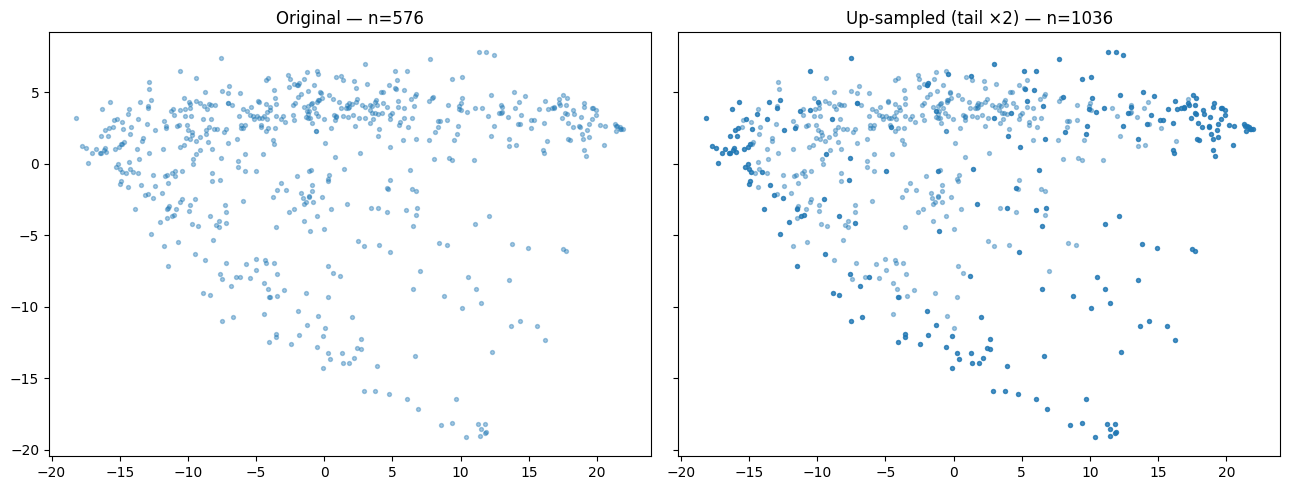

In [ ]:
# === Up-sample đuôi: lặp các fraud outlier để CTGAN cover vùng thưa ===
from sklearn.ensemble import IsolationForest

TAIL_CONTAM = 0.4    # tỉ lệ điểm coi là đuôi (5%)
TAIL_REP    = 2       # số lần lặp đuôi

iso = IsolationForest(contamination=TAIL_CONTAM, random_state=0).fit(fraudDf[FEATURES])
isTail = iso.predict(fraudDf[FEATURES]) == -1
tail = fraudDf[isTail]
fraudDf_train = pd.concat([fraudDf] + [tail] * TAIL_REP, ignore_index=True)

tail_pct = (isTail.sum() * TAIL_REP) / len(fraudDf_train) * 100
print(f'Original fraud:   {len(fraudDf)}')
print(f'Tail detected:    {isTail.sum()} ({isTail.mean()*100:.1f}%)')
print(f'After up-sample:  {len(fraudDf_train)}  (tail share = {tail_pct:.1f}%)')

# Vẽ PCA so sánh trước/sau up-sample
from sklearn.decomposition import PCA
pca2 = PCA(n_components=2, random_state=0).fit(fraudDf[FEATURES].values)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, df, title in zip(axes, [fraudDf, fraudDf_train],
                         ['Original', f'Up-sampled (tail \u00d7{TAIL_REP})']):
    pc = pca2.transform(df[FEATURES].values)
    ax.scatter(pc[:, 0], pc[:, 1], s=8, alpha=0.4)
    ax.set_title(f'{title} \u2014 n={len(df)}')
plt.tight_layout(); plt.show()


In [ ]:
# === BỎ up-sample (chạy cell này nếu muốn train CTGAN trên fraudDf gốc) ===
fraudDf_train = fraudDf.copy()
print(f'fraudDf_train = fraudDf gốc ({len(fraudDf_train)} mẫu, không up-sample).')


fraudDf_train = fraudDf gốc (576 mẫu, không up-sample).


In [ ]:
from sdv.single_table import CTGANSynthesizer
synth = CTGANSynthesizer(
    md, epochs=CTGAN_EPOCHS, batch_size=CTGAN_BATCH,
    discriminator_steps=CTGAN_DSTEPS,
    generator_dim=CTGAN_GEN_DIM, discriminator_dim=CTGAN_DISC_DIM,
    generator_lr=CTGAN_LR, discriminator_lr=CTGAN_LR,
    embedding_dim=CTGAN_EMBED, verbose=True, cuda=False,
)
synth.fit(fraudDf_train)
synth.save(str(MOD_DIR/'ctganModelB.pkl'))
print('Saved', MOD_DIR/'ctganModelB.pkl')

Gen. (-01.25) | Discrim. (+00.50): 100%|█| 800/800 [01:56<00:00,  6.87i

Saved /Users/chinhluu/Personal/Học/An toàn bảo mật trong HTTT/final/notebook/outputs/models/ctganModelB.pkl


In [ ]:
# === Load lại model đã save (skip training nếu kernel vừa restart) ===
# Chạy cell này thay cho cell train ở trên khi đã có ctganModelB.pkl trên disk.
from sdv.single_table import CTGANSynthesizer
synth = CTGANSynthesizer.load(str(MOD_DIR/'ctganModelB.pkl'))
print('Loaded', MOD_DIR/'ctganModelB.pkl')

# Khôi phục thêm fraudDf nếu Section 3 chưa chạy lại sau restart.
if 'fraudDf' not in globals():
    if 'trLog' not in globals():
        trLog = pd.read_csv(DATA_DIR/'trainLog.csv')
    fraudDf = trLog[trLog[LABEL]==1][FEATURES + [LABEL]].copy()
    print('Reloaded fraudDf:', len(fraudDf), 'mẫu')


Loaded /Users/chinhluu/Personal/Học/An toàn bảo mật trong HTTT/final/notebook/outputs/models/ctganModelB.pkl


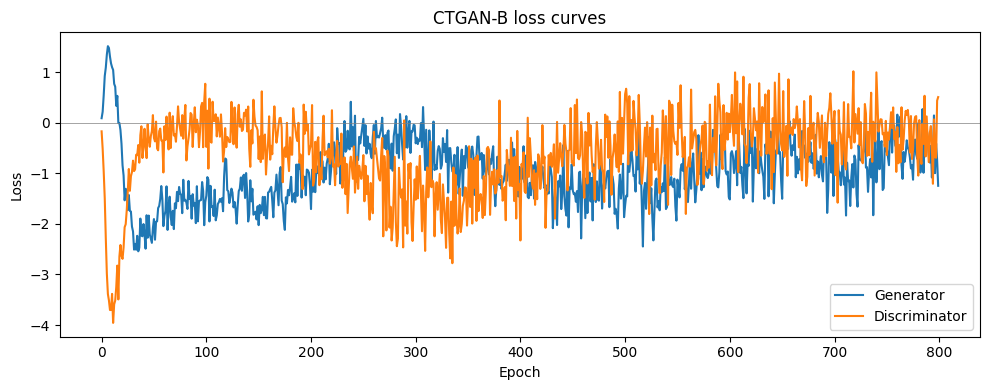

G_last=-1.248  D_last=+0.505


In [ ]:
loss = synth.get_loss_values()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(loss['Epoch'], loss['Generator Loss'], label='Generator')
ax.plot(loss['Epoch'], loss['Discriminator Loss'], label='Discriminator')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('CTGAN-B loss curves'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'ctganLossB.png', dpi=120); plt.show()
loss.to_csv(TAB_DIR/'ctganLossB.csv', index=False)
print(f'G_last={loss["Generator Loss"].iloc[-1]:+.3f}  D_last={loss["Discriminator Loss"].iloc[-1]:+.3f}')

## 5. Sinh dữ liệu + đánh giá fidelity

In [ ]:
# Sinh fraud synth theo tỉ lệ N_SYNTH_RATIO (config ở Section 1).
if 'fraudDf' not in globals():
    if 'trLog' not in globals():
        trLog = pd.read_csv(DATA_DIR/'trainLog.csv')
    fraudDf = trLog[trLog[LABEL]==1][FEATURES + [LABEL]].copy()

N_SYNTH = N_SYNTH_RATIO * len(fraudDf)
synthFraud = synth.sample(num_rows=N_SYNTH)
synthFraud[LABEL] = 1
synthFraud.to_csv(DATA_DIR/'syntheticFraudLogB.csv', index=False)
print(f'Real fraud: {len(fraudDf)}  |  Synth fraud: {len(synthFraud)}  '
      f'(real:synth = 1:{N_SYNTH_RATIO})')


Real fraud: 576  |  Synth fraud: 1152  (real:synth = 1:2)


In [ ]:
from scipy.stats import ks_2samp
rows = []
for c in FEATURES:
    s, p = ks_2samp(fraudDf[c].dropna(), synthFraud[c].dropna())
    rows.append({'feature': c, 'ksStat': s, 'pValue': p})
ksDf = pd.DataFrame(rows).sort_values('ksStat')
ksDf.to_csv(TAB_DIR/'ksTestB.csv', index=False)
print(f"KS mean = {ksDf['ksStat'].mean():.4f}  median = {ksDf['ksStat'].median():.4f}  pass(p>0.05) = {(ksDf['pValue']>0.05).sum()}/{len(ksDf)}")
ksDf.head(10)

KS mean = 0.1496  median = 0.1328  pass(p>0.05) = 2/42


,feature,ksStat,pValue
30,dch_rec,0.067708,0.058234
23,sstk,0.068576,0.053161
29,ch_rsst,0.074653,0.027190
33,ch_cs,0.078993,0.016265
27,prcc_f,0.081597,0.011784
41,ch_fcf,0.086806,0.005994
12,invt,0.093750,0.002280
34,ch_cm,0.095486,0.001770
37,bm,0.096354,0.001556
10,dp,0.099826,0.000920


corrDiff mean = 0.1308


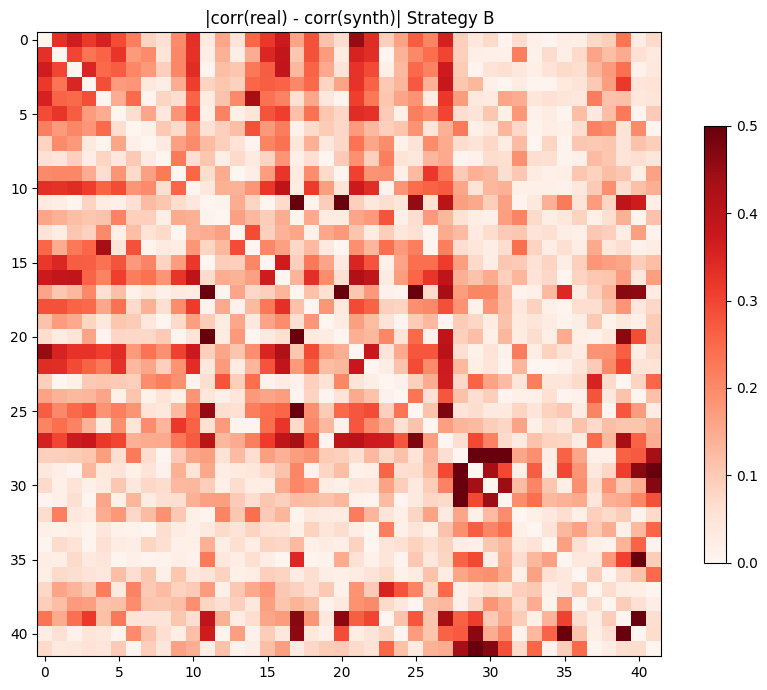

In [ ]:
cr = fraudDf[FEATURES].corr().values
cs = synthFraud[FEATURES].corr().values
diff = np.abs(cr - cs)
print(f'corrDiff mean = {diff.mean():.4f}')
fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(diff, cmap='Reds', vmin=0, vmax=0.5)
ax.set_title('|corr(real) - corr(synth)| Strategy B')
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.savefig(FIG_DIR/'corrDiffB.png', dpi=120); plt.show()

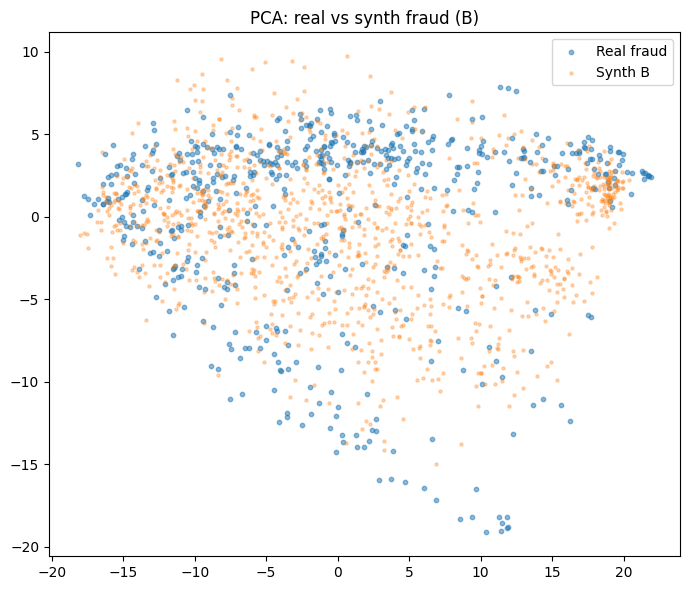

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=0)
rv = pca.fit_transform(fraudDf[FEATURES].values)
sv = pca.transform(synthFraud[FEATURES].values)
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(rv[:,0], rv[:,1], s=10, alpha=0.5, label='Real fraud')
ax.scatter(sv[:,0], sv[:,1], s=5,  alpha=0.3, label='Synth B')
ax.legend(); ax.set_title('PCA: real vs synth fraud (B)')
plt.tight_layout(); plt.savefig(FIG_DIR/'pcaRealVsSynthB.png', dpi=120); plt.show()

## 6. Train classifier 

Augmentation: trộn synthetic fraud vào train sao cho neg ≈ 2 × pos. Train 4 model × 5 seed.

In [ ]:
import time, traceback

# === Luôn reload synth để cập nhật khi đổi N_SYNTH ===
trS = pd.read_csv(DATA_DIR/'train.csv')
vaS = pd.read_csv(DATA_DIR/'val.csv')
teS = pd.read_csv(DATA_DIR/'test.csv')
scaler = joblib.load(MOD_DIR/'scaler.joblib')
synthFraud = pd.read_csv(DATA_DIR/'syntheticFraudLogB.csv')
synthScaled = synthFraud.copy()
synthScaled[FEATURES] = scaler.transform(synthFraud[FEATURES])
synthScaled[LABEL] = 1
print(f'Loaded synth: {len(synthFraud)} rows')

# === Helpers ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.ensemble import RUSBoostClassifier
from xgboost import XGBClassifier

def xy(d): return d[FEATURES].values, d[LABEL].astype(int).values

def buildCtganAug(t, sy):
    neg = (t[LABEL]==0).sum(); pos = (t[LABEL]==1).sum()
    need = max(0, neg - 2*pos)
    add = sy[FEATURES + [LABEL]].sample(n=min(need, len(sy)), random_state=0)
    return pd.concat([t, add], ignore_index=True)

def makeModel(name, seed):
    if name == 'LR':
        return LogisticRegression(max_iter=2000, random_state=seed, n_jobs=1)
    if name == 'RF':
        return RandomForestClassifier(n_estimators=300, max_depth=12, n_jobs=1, random_state=seed)
    if name == 'XGB':
        # v2: scale_pos_weight để xử imbalance 1:200
        return XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                             eval_metric='aucpr', random_state=seed, n_jobs=1,
                             tree_method='hist',
                             scale_pos_weight=XGB_SCALE_POS_WEIGHT)
    if name == 'RUSBoost':
        return RUSBoostClassifier(n_estimators=300, learning_rate=0.1, random_state=seed)
    raise ValueError(name)

def ndcgAtK(yT, yP, k):
    order = np.argsort(-yP); rel = yT[order][:k].astype(float)
    disc = 1.0/np.log2(np.arange(2, k+2))
    dcg = float((rel*disc).sum())
    nPos = int(yT.sum())
    if nPos == 0: return 0.0
    idcg = float(disc[:min(nPos,k)].sum())
    return dcg/idcg if idcg>0 else 0.0

def sensAtK(yT, yP, kFrac):
    n = len(yT); k = max(1, int(np.ceil(kFrac*n)))
    order = np.argsort(-yP)
    nPos = int(yT.sum())
    return int(yT[order][:k].sum())/nPos if nPos>0 else 0.0

modelNames = ['LR','XGB']
scenarios = {
    'baseline':  lambda: trS.copy(),
    'ctganAugB': lambda: buildCtganAug(trS, synthScaled),
}

def runPhase(eval_set, eval_name):
    """Train trên scenarios, đánh giá trên eval_set (val hoặc test)."""
    rows, probas = [], {}
    xe, ye = xy(eval_set)
    for seed in SEEDS:
        for sName, builder in scenarios.items():
            train = builder()
            xt, yt = xy(train)
            for mName in modelNames:
                t0 = time.time()
                try:
                    mdl = makeModel(mName, seed)
                    mdl.fit(xt, yt)
                    pe = mdl.predict_proba(xe)[:, 1]
                except Exception as e:
                    print(f"[{sName:10s} {mName:8s}] LỖI: {type(e).__name__}: {e}")
                    traceback.print_exc(); continue
                row = {'phase': eval_name, 'scenario': sName, 'model': mName, 'seed': seed,
                       'rocAuc': roc_auc_score(ye, pe),
                       'prAuc':  average_precision_score(ye, pe)}
                for kp in K_PERCENTS:
                    kAbs = max(1, int(np.ceil(kp/100.0 * len(ye))))
                    row[f'ndcg@{kp}'] = ndcgAtK(ye, pe, kAbs)
                    row[f'sens@{kp}'] = sensAtK(ye, pe, kp/100.0)
                rows.append(row)
                probas[f'{eval_name}_{sName}_{mName}_{seed}'] = pe
                ytKey = f'{eval_name}_{sName}_{mName}_yTrue'
                if ytKey not in probas: probas[ytKey] = ye
                print(f"[{eval_name:4s} | {sName:10s} {mName:8s} seed={seed}] "
                      f"{time.time()-t0:5.1f}s  AUC={row['rocAuc']:.3f} "
                      f"PR={row['prAuc']:.4f} NDCG@1={row['ndcg@1']:.3f}")
    return pd.DataFrame(rows), probas

# === Phase 1: chọn variant trên VAL ===
print('===== PHASE 1: VALIDATION =====')
val_results, val_probas = runPhase(vaS, 'val')
val_results.to_csv(TAB_DIR/'results_val.csv', index=False)

# === Phase 2: đánh giá cuối trên TEST ===
print('\n===== PHASE 2: TEST =====')
test_results, test_probas = runPhase(teS, 'test')
test_results.to_csv(TAB_DIR/'results.csv', index=False)

# Gộp probas
all_probas = {**val_probas, **test_probas}
np.savez_compressed(TAB_DIR/'probas.npz', **all_probas)

# Show side-by-side: best variant on val, kết quả trên test
print('\n===== Tóm tắt =====')
print('VAL:')
print(val_results.pivot_table(index='model', columns='scenario', values='rocAuc', aggfunc='mean').round(4))
print('\nTEST:')
print(test_results.pivot_table(index='model', columns='scenario', values='rocAuc', aggfunc='mean').round(4))

# === Alias cho các cell đánh giá phía dưới (Section 7) ===
# Section 7 dùng `results` + `probas` với key {scenario}_{model}_{seed}.
# Map test_results -> results, strip prefix 'test_' khỏi probas keys.
results = test_results.copy()
probas = {k[len('test_'):]: v for k, v in test_probas.items() if k.startswith('test_')}
print(f'Aliased: results={len(results)} rows, probas={len(probas)} keys.')


Loaded synth: 1152 rows
===== PHASE 1: VALIDATION =====
[val  | baseline   LR       seed=42]   0.1s  AUC=0.764 PR=0.0328 NDCG@1=0.061
[val  | baseline   XGB      seed=42]   3.4s  AUC=0.793 PR=0.0584 NDCG@1=0.123
[val  | ctganAugB  LR       seed=42]   0.2s  AUC=0.714 PR=0.0230 NDCG@1=0.043
[val  | ctganAugB  XGB      seed=42]   4.0s  AUC=0.804 PR=0.0575 NDCG@1=0.119
[val  | baseline   LR       seed=7]   0.1s  AUC=0.764 PR=0.0328 NDCG@1=0.061
[val  | baseline   XGB      seed=7]   3.5s  AUC=0.793 PR=0.0584 NDCG@1=0.123
[val  | ctganAugB  LR       seed=7]   0.2s  AUC=0.714 PR=0.0230 NDCG@1=0.043
[val  | ctganAugB  XGB      seed=7]   3.7s  AUC=0.804 PR=0.0575 NDCG@1=0.119
[val  | baseline   LR       seed=123]   0.1s  AUC=0.764 PR=0.0328 NDCG@1=0.061
[val  | baseline   XGB      seed=123]   3.5s  AUC=0.793 PR=0.0584 NDCG@1=0.123
[val  | ctganAugB  LR       seed=123]   0.2s  AUC=0.714 PR=0.0230 NDCG@1=0.043
[val  | ctganAugB  XGB      seed=123]   3.8s  AUC=0.804 PR=0.0575 NDCG@1=0.119

===== P

## 7. Đánh giá tổng hợp

In [ ]:
metricCols = ['rocAuc','prAuc','ndcg@5','ndcg@10','sens@5','sens@10']
summary = (results.groupby(['model','scenario'])[metricCols]
           .agg(['mean','std']).round(4))
summary.to_csv(TAB_DIR/'summary.csv')

# Bảng delta: ctganAugB - baseline (chỉ mean), giúp thấy nhanh GAN có giúp không
mean_only = results.groupby(['model','scenario'])[metricCols].mean().round(4)
delta = (mean_only.xs('ctganAugB', level='scenario')
         - mean_only.xs('baseline', level='scenario')).round(4)
delta.to_csv(TAB_DIR/'delta_ctganAugB_minus_baseline.csv')
print('=== DELTA (ctganAugB - baseline), >0 nghĩa là augment có giúp ===')
print(delta)
print('\n=== Summary mean ± std ===')
summary


=== DELTA (ctganAugB - baseline), >0 nghĩa là augment có giúp ===
       rocAuc  prAuc  ndcg@5  ndcg@10  sens@5  sens@10
model                                                 
LR    -0.0151  0.001  0.0301   0.0245   0.045   0.0337
XGB    0.0341  0.001  0.0173   0.0366   0.045   0.0899

=== Summary mean ± std ===


rocAuc        prAuc       ndcg@5      ndcg@10       sens@5  \
                   mean  std    mean  std    mean  std    mean  std    mean   
model scenario                                                                
LR    baseline   0.6760  0.0  0.0086  0.0  0.0367  0.0  0.0778  0.0  0.0674   
      ctganAugB  0.6609  0.0  0.0096  0.0  0.0668  0.0  0.1023  0.0  0.1124   
XGB   baseline   0.6482  0.0  0.0081  0.0  0.0398  0.0  0.0753  0.0  0.0674   
      ctganAugB  0.6823  0.0  0.0091  0.0  0.0571  0.0  0.1119  0.0  0.1124   

                     sens@10       
                 std    mean  std  
model scenario                     
LR    baseline   0.0  0.1573  0.0  
      ctganAugB  0.0  0.1910  0.0  
XGB   baseline   0.0  0.1461  0.0  
      ctganAugB  0.0  0.2360  0.0

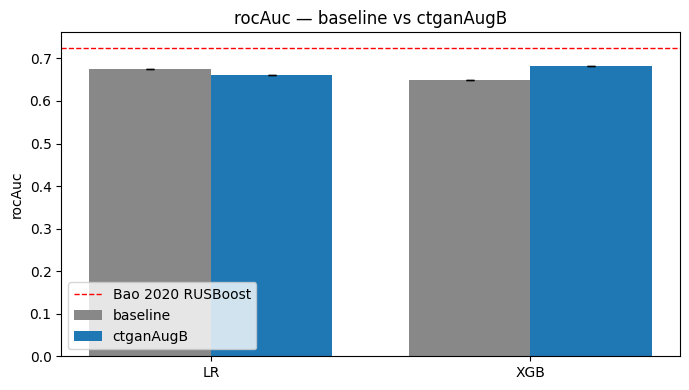

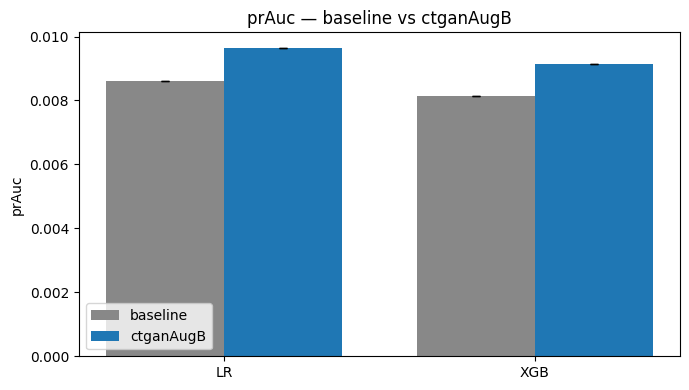

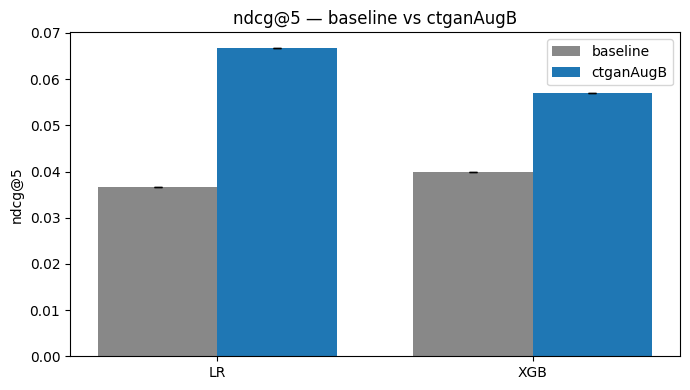

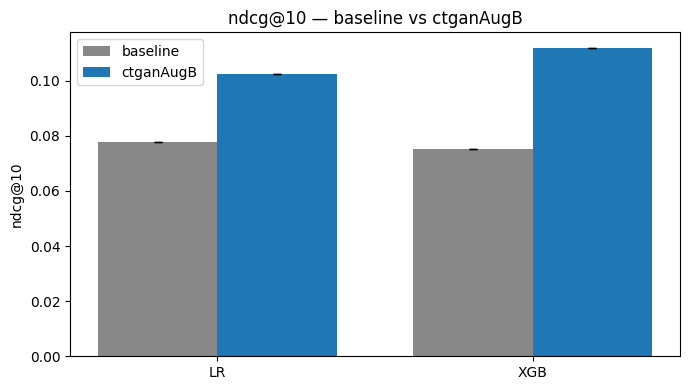

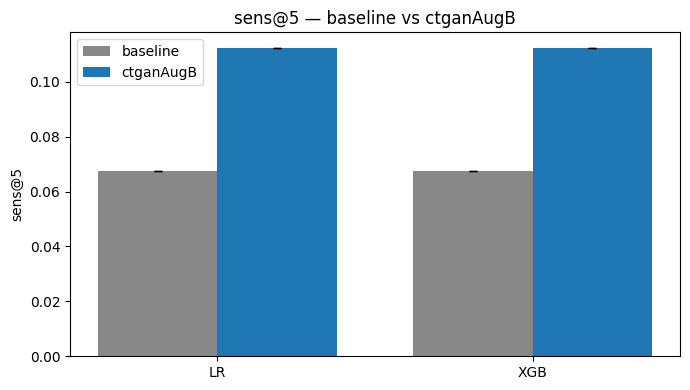

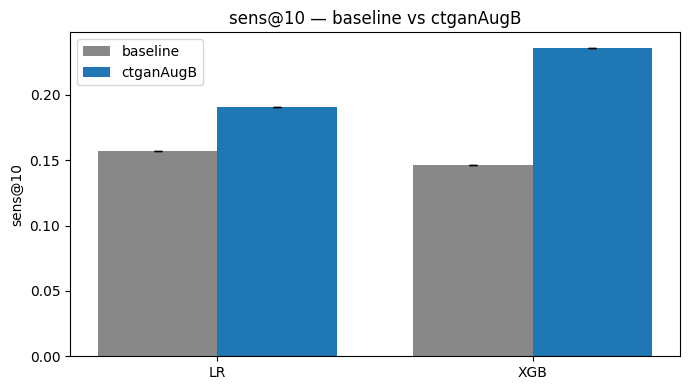

In [ ]:
scenOrder = ['baseline', 'ctganAugB']
colors = {'baseline': '#888888', 'ctganAugB': '#1f77b4'}
x = np.arange(len(modelNames)); width = 0.38

for metric in ['rocAuc','prAuc','ndcg@5','ndcg@10','sens@5','sens@10']:
    fig, ax = plt.subplots(figsize=(7,4))
    for i, sc in enumerate(scenOrder):
        sub = results[results.scenario==sc]
        means = sub.groupby('model')[metric].mean().reindex(modelNames)
        stds  = sub.groupby('model')[metric].std().reindex(modelNames)
        ax.bar(x + (i-0.5)*width, means, width, yerr=stds, capsize=3,
               label=sc, color=colors[sc])
    ax.set_xticks(x); ax.set_xticklabels(modelNames)
    ax.set_title(f'{metric} — baseline vs ctganAugB'); ax.set_ylabel(metric)
    if metric == 'rocAuc':
        ax.axhline(0.7251, ls='--', color='red', lw=1, label='Bao 2020 RUSBoost')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR/f'bar_{metric.replace("@","At")}.png', dpi=120)
    plt.show()


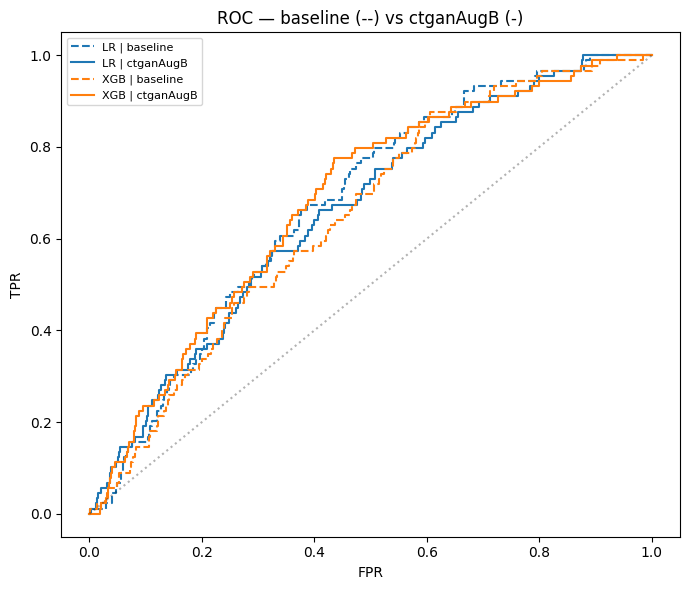

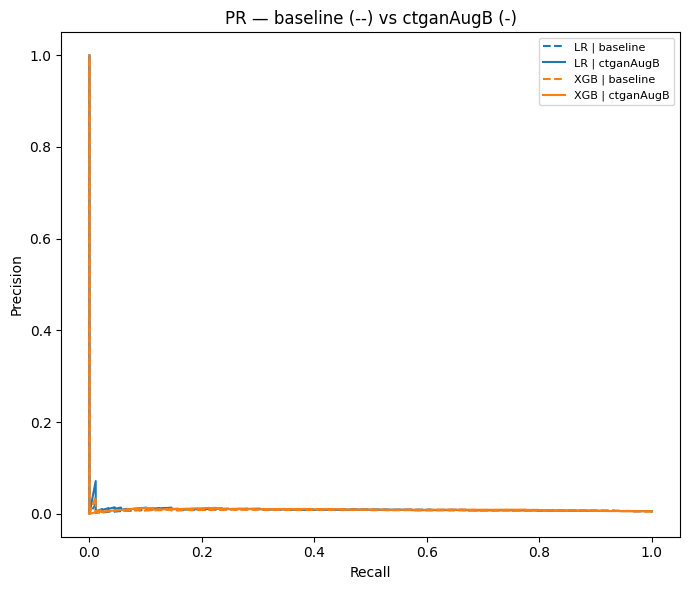

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve
seed0 = SEEDS[0]
ls_map = {'baseline': '--', 'ctganAugB': '-'}

figR, axR = plt.subplots(figsize=(7,6))
figP, axP = plt.subplots(figsize=(7,6))
cmap = plt.get_cmap('tab10')
for i, m in enumerate(modelNames):
    color = cmap(i)
    for sc in scenOrder:
        ytKey = f'{sc}_{m}_yTrue'; ypKey = f'{sc}_{m}_{seed0}'
        if ytKey not in probas or ypKey not in probas:
            continue
        yt = probas[ytKey]; yp = probas[ypKey]
        fpr, tpr, _ = roc_curve(yt, yp)
        axR.plot(fpr, tpr, ls=ls_map[sc], color=color, label=f'{m} | {sc}')
        pr, rc, _ = precision_recall_curve(yt, yp)
        axP.plot(rc, pr, ls=ls_map[sc], color=color, label=f'{m} | {sc}')
axR.plot([0,1],[0,1],'k:', alpha=0.3)
axR.set_xlabel('FPR'); axR.set_ylabel('TPR'); axR.set_title('ROC — baseline (--) vs ctganAugB (-)')
axR.legend(fontsize=8)
axP.set_xlabel('Recall'); axP.set_ylabel('Precision'); axP.set_title('PR — baseline (--) vs ctganAugB (-)')
axP.legend(fontsize=8)
figR.tight_layout(); figP.tight_layout()
figR.savefig(FIG_DIR/'roc.png', dpi=120); figP.savefig(FIG_DIR/'pr.png', dpi=120)
plt.show()


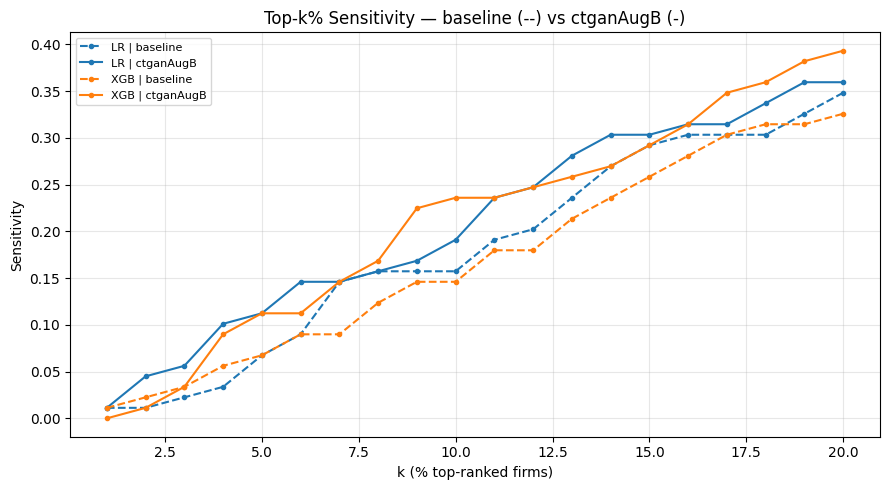

In [ ]:
ks = np.arange(1, 21)
fig, ax = plt.subplots(figsize=(9,5))
cmap = plt.get_cmap('tab10')
for i, m in enumerate(modelNames):
    color = cmap(i)
    for sc in scenOrder:
        ytKey = f'{sc}_{m}_yTrue'; ypKey = f'{sc}_{m}_{seed0}'
        if ytKey not in probas or ypKey not in probas:
            continue
        yt = probas[ytKey]; yp = probas[ypKey]
        order = np.argsort(-yp); ytSort = yt[order]
        nPos = max(1, int(yt.sum())); n = len(yt)
        sens = []
        for kp in ks:
            kAbs = max(1, int(np.ceil(kp/100.0 * n)))
            sens.append(ytSort[:kAbs].sum()/nPos)
        ax.plot(ks, sens, marker='o', ms=3, ls=ls_map[sc],
                color=color, label=f'{m} | {sc}')
ax.set_xlabel('k (% top-ranked firms)'); ax.set_ylabel('Sensitivity')
ax.set_title('Top-k% Sensitivity — baseline (--) vs ctganAugB (-)')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/'sensTopK.png', dpi=120); plt.show()


### 7.5 Feature importance (XGBoost)

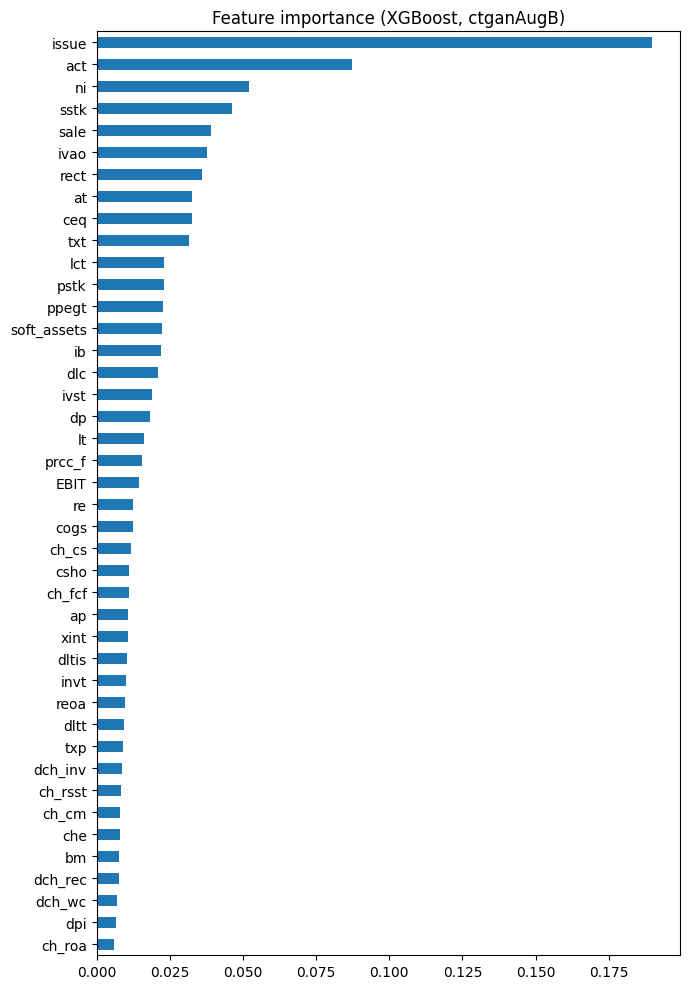

In [ ]:
trainAll = buildCtganAug(trS, synthScaled)
xa, ya = xy(trainAll)
xgbImp = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                       eval_metric='aucpr', random_state=SEEDS[0], tree_method='hist')
xgbImp.fit(xa, ya)
imp = pd.Series(xgbImp.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp.to_csv(TAB_DIR/'featureImportance.csv', header=['importance'])
fig, ax = plt.subplots(figsize=(7,10))
imp.plot(kind='barh', ax=ax); ax.set_title('Feature importance (XGBoost, ctganAugB)')
plt.tight_layout(); plt.savefig(FIG_DIR/'featureImportance.png', dpi=120); plt.show()

## 8. Privacy DCR

Distance to Closest Record: với mỗi mẫu synth (hoặc holdout), tính khoảng cách Euclidean tới fraud thật gần nhất trong train. Synth có DCR ≥ holdout → coi như không quá gần dữ liệu train.

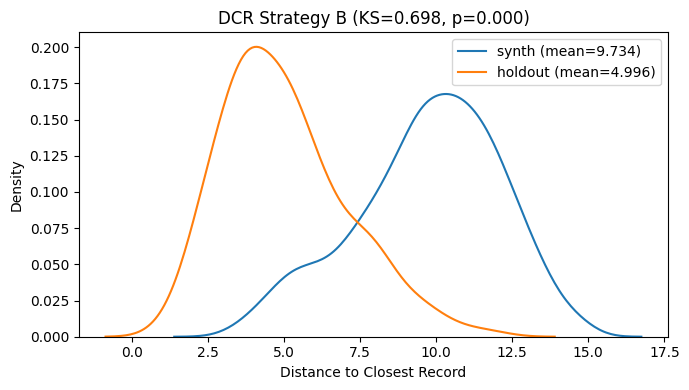

mean DCR synth = 9.7340  | holdout = 4.9962  → AN TOÀN


In [ ]:
from sklearn.neighbors import NearestNeighbors
trainFraud = trLog[trLog[LABEL]==1][FEATURES].values
holdoutFraud = vaLog[vaLog[LABEL]==1][FEATURES].values
if len(holdoutFraud) < 5:
    holdoutFraud = vaLog[FEATURES].sample(n=min(len(vaLog),5000), random_state=0).values
synthX = synthFraud[FEATURES].sample(n=min(len(synthFraud),5000), random_state=0).values

def computeDcr(s, r):
    nn = NearestNeighbors(n_neighbors=1).fit(r)
    d, _ = nn.kneighbors(s); return d.flatten()

dcrSynth = computeDcr(synthX, trainFraud)
dcrHold  = computeDcr(holdoutFraud, trainFraud)
stat, p = ks_2samp(dcrSynth, dcrHold)

fig, ax = plt.subplots(figsize=(7,4))
sns.kdeplot(dcrSynth, label=f'synth (mean={dcrSynth.mean():.3f})', ax=ax)
sns.kdeplot(dcrHold,  label=f'holdout (mean={dcrHold.mean():.3f})', ax=ax)
ax.set_title(f'DCR Strategy B (KS={stat:.3f}, p={p:.3f})')
ax.set_xlabel('Distance to Closest Record'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'dcrB.png', dpi=120); plt.show()
verdict = 'AN TOÀN' if dcrSynth.mean() >= dcrHold.mean() else 'CẦN KIỂM TRA THÊM'
print(f'mean DCR synth = {dcrSynth.mean():.4f}  | holdout = {dcrHold.mean():.4f}  → {verdict}')
pd.DataFrame([{'meanDcrSynth': dcrSynth.mean(), 'meanDcrHoldout': dcrHold.mean(),
               'ks': stat, 'pValue': p, 'verdict': verdict}]).to_csv(TAB_DIR/'dcrSummary.csv', index=False)